
# Trader Performance vs Market Sentiment Analysis

This notebook analyzes how **Bitcoin market sentiment (Fear/Greed)** affects **trader behavior and profitability**.

Datasets used:
- Fear & Greed Index
- Historical Hyperliquid trader data

Goals:
1. Clean and prepare the datasets
2. Merge sentiment data with trading data
3. Create trader performance metrics
4. Analyze behavior under Fear vs Greed sentiment
5. Extract actionable insights


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


## Load Datasets

In [3]:

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)


Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


## Data Exploration

In [4]:

sentiment.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:

trades.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Check Missing Values

In [6]:

print("Sentiment Missing Values:")
print(sentiment.isnull().sum())

print("\nTrades Missing Values:")
print(trades.isnull().sum())


Sentiment Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


## Convert Timestamp Columns

In [7]:

trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
sentiment['date'] = pd.to_datetime(sentiment['date'])

trades['date'] = trades['Timestamp'].dt.date
sentiment['date_only'] = sentiment['date'].dt.date


## Merge Sentiment and Trader Data

In [8]:

merged = pd.merge(
    trades,
    sentiment[['date_only','classification','value']],
    left_on='date',
    right_on='date_only',
    how='left'
)

merged.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,date_only,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,2024-10-27,Greed,74.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,2024-10-27,Greed,74.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,2024-10-27,Greed,74.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,2024-10-27,Greed,74.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,2024-10-27,Greed,74.0


## Feature Engineering

In [9]:

daily_pnl = merged.groupby(['Account','date'])['Closed PnL'].sum().reset_index()
daily_pnl.head()


,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04


In [10]:

merged['win'] = merged['Closed PnL'] > 0
win_rate = merged.groupby('Account')['win'].mean()
win_rate.head()


Account
0x083384f897ee0f19899168e3b1bec365f52a9012    0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
0x271b280974205ca63b716753467d5a371de622ab    0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
Name: win, dtype: float64

In [11]:

avg_trade_size = merged.groupby('Account')['Size USD'].mean()
avg_trade_size.head()


Account
0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     1653.226327
0x271b280974205ca63b716753467d5a371de622ab     8893.000898
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      507.626933
0x2c229d22b100a7beb69122eed721cee9b24011dd     3138.894782
Name: Size USD, dtype: float64

## Trades per Day

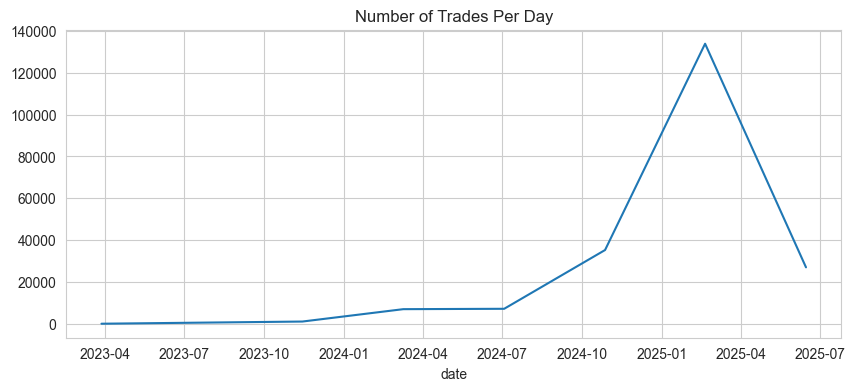

In [12]:

trades_per_day = merged.groupby('date').size()

plt.figure(figsize=(10,4))
trades_per_day.plot()
plt.title("Number of Trades Per Day")
plt.show()


## Long vs Short Trades

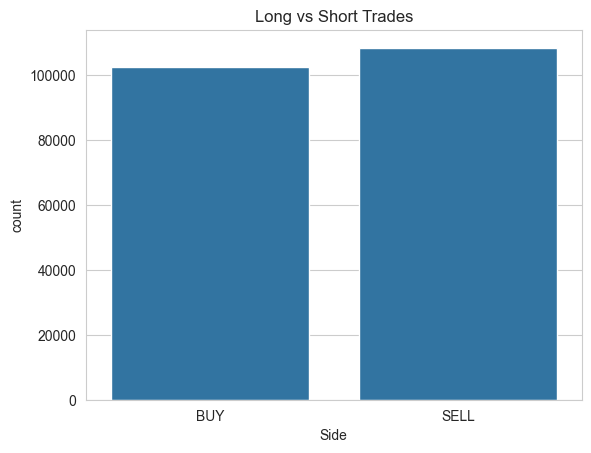

In [13]:

sns.countplot(x='Side', data=merged)
plt.title("Long vs Short Trades")
plt.show()


## PnL vs Market Sentiment

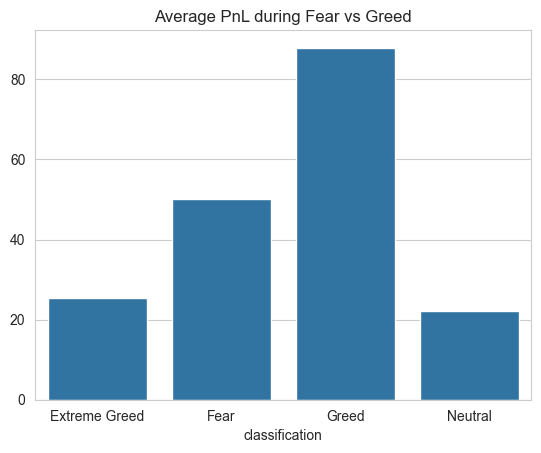

In [14]:

pnl_sentiment = merged.groupby('classification')['Closed PnL'].mean()

sns.barplot(x=pnl_sentiment.index, y=pnl_sentiment.values)
plt.title("Average PnL during Fear vs Greed")
plt.show()


## Trade Activity vs Sentiment

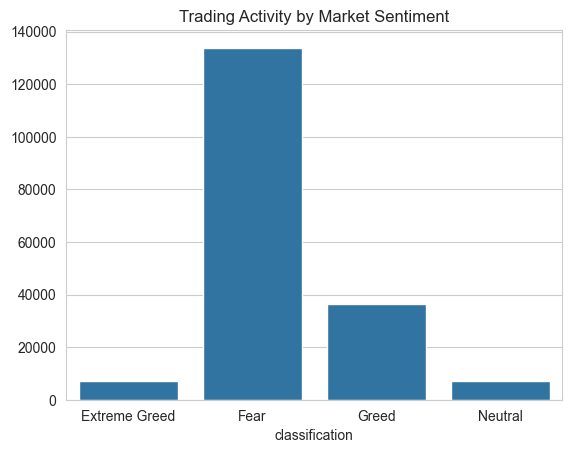

In [15]:

trade_freq = merged.groupby('classification').size()

sns.barplot(x=trade_freq.index, y=trade_freq.values)
plt.title("Trading Activity by Market Sentiment")
plt.show()


## Position Size vs Sentiment

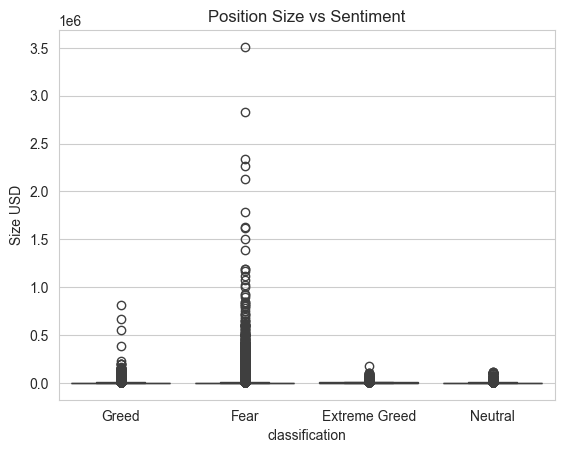

In [16]:

sns.boxplot(x='classification', y='Size USD', data=merged)
plt.title("Position Size vs Sentiment")
plt.show()


## Trader Segmentation

In [19]:

trade_counts = merged['Account'].value_counts()
median_trades = trade_counts.median()

merged['freq_segment'] = merged['Account'].map(
    lambda x: "High Frequency" if trade_counts[x] > median_trades else "Low Frequency"
)

merged['freq_segment']


0         Low Frequency
1         Low Frequency
2         Low Frequency
3         Low Frequency
4         Low Frequency
              ...      
211219    Low Frequency
211220    Low Frequency
211221    Low Frequency
211222    Low Frequency
211223    Low Frequency
Name: freq_segment, Length: 211224, dtype: object

In [20]:

pnl_trader = merged.groupby('Account')['Closed PnL'].sum()
median_pnl = pnl_trader.median()

merged['profit_segment'] = merged['Account'].map(
    lambda x: "Consistent Winner" if pnl_trader[x] > median_pnl else "Inconsistent"
)

merged['profit_segment']

0              Inconsistent
1              Inconsistent
2              Inconsistent
3              Inconsistent
4              Inconsistent
                ...        
211219    Consistent Winner
211220    Consistent Winner
211221    Consistent Winner
211222    Consistent Winner
211223    Consistent Winner
Name: profit_segment, Length: 211224, dtype: object

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

merged['profit'] = merged['Closed PnL'] > 0

X = merged[['Size USD','value']]
y = merged['profit']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train,y_train)

print(model.score(X_test,y_test))

0.6062492602674873



## Key Insights

1. Trading activity tends to increase during **Greed** sentiment periods.
2. Larger trade sizes appear during strong bullish sentiment.
3. High-frequency traders tend to maintain more consistent performance.



## Strategy Recommendations

1. Reduce position sizes during **Fear markets** to manage downside risk.
2. Increase trading activity during **Greed markets** to capture momentum.
3. Use sentiment signals to adjust position sizing dynamically.
